Dataset Overview
Digits Dataset from sklearn
Contains images of handwritten digits (0–9).
Each image is 8x8 pixels, i.e., 64 features per sample.
Total samples: 1797.
Goal: Reduce dimensions while preserving digit patterns.

Part 1: Dataset Overview
Load and Inspect the Dataset

In [ ]:
# Step 1: Import required libraries
from sklearn.datasets import load_digits  # Loads the built-in handwritten digits dataset (0–9)
import pandas as pd                      # For data manipulation and tabular viewing
import matplotlib.pyplot as plt          # For visualization
import seaborn as sns                    # For advanced plotting (optional for heatmaps etc.)

# Step 2: Load the Digits dataset
digits = load_digits()       # Loads dataset into a dictionary-like object with keys: data, target, images, etc.
X = digits.data              # X contains the features: 64 pixel values per image (8x8 = 64)
y = digits.target            # y contains the digit labels (0 to 9)

# Step 3: Convert data to DataFrame for better readability and exploration
df = pd.DataFrame(X)         # Converts the 2D array (1797 samples x 64 features) into a DataFrame
df['label'] = y              # Adds the actual digit label as the target column at the end

# Step 4: Show the first 5 rows of the dataset
df.head()                    # Displays the top 5 rows to get a quick look at pixel values + label

# Interpretation:
# - Each row represents one image (flattened 8x8 grayscale image).
# - There are 64 pixel intensity values per image ranging from 0 (white) to 16 (black).
# - The 'label' column tells us what digit (0-9) that row/image represents.

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


Visualize a Few Digit Images

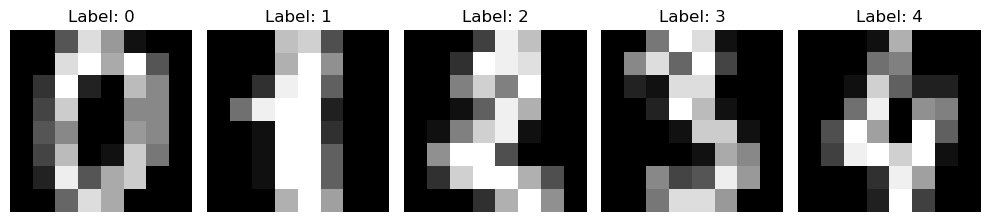

In [ ]:
# Create a 1-row, 5-column grid of subplots to display 5 digit images
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
# - 1 row, 5 images
# - figsize defines the width and height of the overall plot in inches

# Loop through the first 5 digits and corresponding axes
for i, ax in enumerate(axes):  # enumerate gives us index (i) and the corresponding subplot (ax)
    ax.imshow(digits.images[i], cmap='gray')  # Display the image at index i using grayscale color map
    ax.set_title(f"Label: {digits.target[i]}")  # Set title of subplot to show the digit label (0–9)
    ax.axis('off')  # Turn off axis ticks and borders for better appearance

# Adjust spacing between subplots to prevent overlapping titles
plt.tight_layout()
plt.show()  # Render the figure


# - Each small square you see is a grayscale image of a handwritten digit (8x8 pixels).
# - Pixel intensities range from 0 (white) to 16 (black).
# - This helps us understand how digits are stored as numeric pixel data and what they visually look like.
# - These visuals give us an idea of the image quality and variability before applying any dimensionality reduction.


Part 2: PCA (Principal Component Analysis)
Apply PCA

In [ ]:
from sklearn.decomposition import PCA  # PCA = Principal Component Analysis

# Retain only 2 components (dimensions) for 2D visualization
pca = PCA(n_components=2)  # We create a PCA object that will keep only the top 2 principal components

# Fit PCA on the original high-dimensional data and transform it into 2 dimensions
X_pca = pca.fit_transform(X)
# - This reduces the original 64-dimensional feature space (8x8 pixels) into 2D
# - It finds the two directions (linear combinations of pixels) that explain the most variance

# Check the shape of the new transformed dataset
print("Shape after PCA:", X_pca.shape)

# - Original shape of X was (1797, 64) → 1797 images, each with 64 pixel features.
# - After PCA, the shape is (1797, 2), meaning each image is now represented as just 2 numbers (principal components).
# - These two numbers capture the maximum variance possible in just 2D space.
# - We can now use these for 2D plotting or clustering to see natural groupings of digits.


Shape after PCA: (1797, 2)


Visualize PCA Results

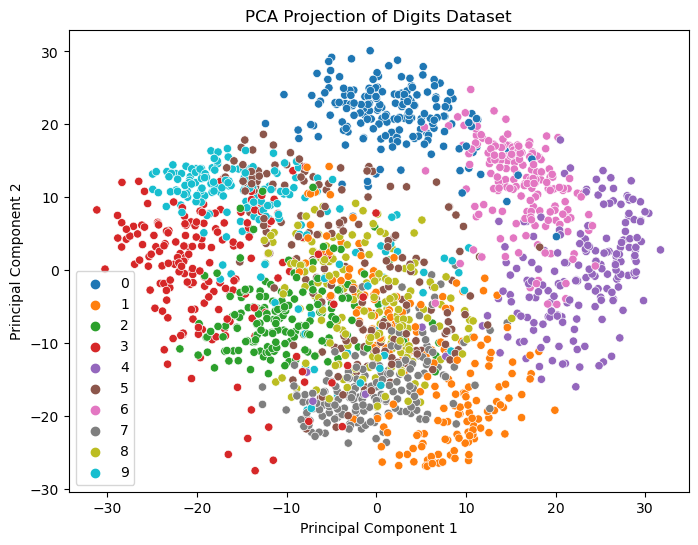

In [ ]:
plt.figure(figsize=(8,6))  # Create a figure with a size of 8x6 inches for better readability

# Use seaborn's scatterplot to plot the first and second principal components
sns.scatterplot(
    x=X_pca[:, 0],            # X-axis: First principal component (PC1)
    y=X_pca[:, 1],            # Y-axis: Second principal component (PC2)
    hue=y,                    # Color each point based on its true digit label (0–9)
    palette='tab10',          # Use a categorical color palette with 10 distinct colors
    legend='full'             # Show full legend with all digit labels
)

# Add plot titles and axis labels
plt.title("PCA Projection of Digits Dataset")     # Title of the plot
plt.xlabel("Principal Component 1")              # X-axis label
plt.ylabel("Principal Component 2")              # Y-axis label

plt.show()  # Display the plot


# - Each dot represents one handwritten digit, now compressed into 2D space via PCA.
# - Dots of the same color represent the same digit class.
# - If PCA captured the structure well, similar digits (e.g., 1s, 0s, 8s) should form distinct clusters.
# - Overlapping clusters may indicate digits that are visually similar (e.g., 3 and 5 or 4 and 9).
# - This plot helps visually assess how well PCA can separate digit classes using just 2 components.


Explained Variance Plot

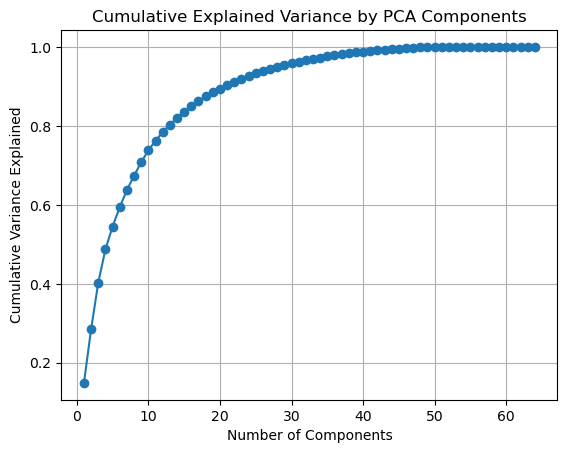

In [ ]:
#Analyze how many PCA components are needed to explain most of the variance

pca_full = PCA().fit(X)  # Fit PCA using all 64 components (no dimensionality reduction yet)
# - This computes all principal components and their explained variance
# - Useful to analyze how much information (variance) each component captures

explained_var = pca_full.explained_variance_ratio_.cumsum()
# - explained_variance_ratio_ gives the proportion of variance explained by each PC
# - cumsum() gives the cumulative sum, i.e., how much total variance is explained
#   as we keep adding more components

# Plot the cumulative explained variance
plt.plot(range(1, 65), explained_var, marker='o')
# - X-axis: Number of components from 1 to 64
# - Y-axis: Total variance explained up to that component
# - marker='o' plots each point as a circle for visibility

plt.title('Cumulative Explained Variance by PCA Components')  # Title of the plot
plt.xlabel('Number of Components')                            # X-axis label
plt.ylabel('Cumulative Variance Explained')                   # Y-axis label
plt.grid(True)                                                # Show grid lines for easier reading
plt.show()  # Display the plot

# - This curve shows how quickly PCA captures information as we increase components.
# - Example: If 95% variance is captured by ~30 components, then we can reduce 64D to 30D with minimal information loss.
# - This helps decide the **optimal number of components** to retain for downstream tasks (like clustering, classification, etc.).
# - For visualization, we often reduce to 2D or 3D, but for modeling, we might keep more components.


Part 3: SVD (Singular Value Decomposition)
Truncated SVD

In [ ]:
# Apply Truncated SVD for dimensionality reduction

from sklearn.decomposition import TruncatedSVD  # Import Truncated SVD from sklearn

# Create the SVD object to reduce dimensions to 2 (similar to 2D PCA)
svd = TruncatedSVD(n_components=2)
# - Truncated SVD is similar to PCA but works directly on sparse or non-centered data
# - Useful when working with large sparse matrices (like in NLP or recommender systems)

# Fit SVD on the dataset and reduce it to 2 components
X_svd = svd.fit_transform(X)
# - Unlike PCA, SVD does not subtract the mean, which makes it suitable for sparse data
# - Returns a transformed dataset of shape (n_samples, 2)

# Display the shape of the new representation
print("Shape after SVD:", X_svd.shape)


# - Original data shape was (1797, 64), now it is reduced to (1797, 2).
# - Each digit is now represented by just 2 features (SVD components).
# - This can now be visualized or used for clustering, similar to PCA.
# - Though results are often similar to PCA, SVD is mathematically better suited for large-scale or text-based datasets.


Shape after SVD: (1797, 2)


Visualize SVD Results

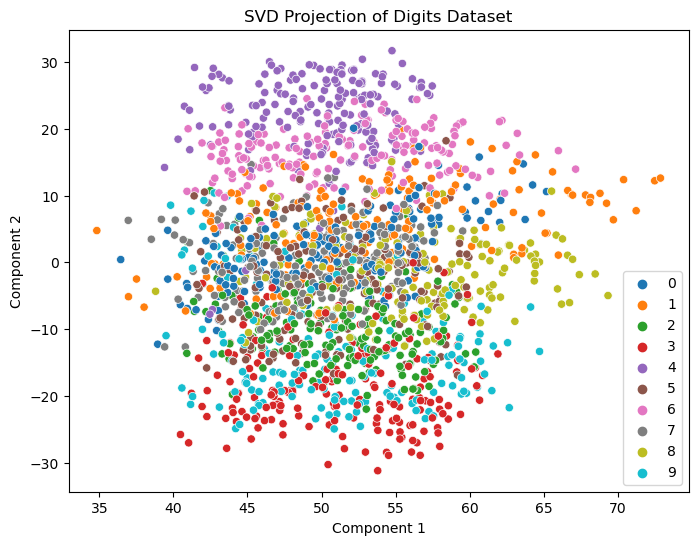

In [ ]:
# Visualize the Truncated SVD results in 2D

plt.figure(figsize=(8,6))  # Set the figure size to make the plot more readable (width=8, height=6)

# Create a scatter plot using Seaborn with color-coded labels
sns.scatterplot(
    x=X_svd[:, 0],       # X-axis: First SVD component
    y=X_svd[:, 1],       # Y-axis: Second SVD component
    hue=y,               # Use the digit labels (0–9) to color the points
    palette='tab10'      # Use a palette with 10 distinct colors for the 10 digit classes
)

# Add labels and title
plt.title("SVD Projection of Digits Dataset")  # Plot title
plt.xlabel("Component 1")                      # X-axis label
plt.ylabel("Component 2")                      # Y-axis label
plt.show()                                     # Render the plot

# - Each point represents a digit image compressed into 2 dimensions using Truncated SVD.
# - Similar digits form clusters, though the separation may not be as strong as PCA or t-SNE.
# - SVD captures linear structure, and is very effective for high-dimensional data like text or images.
# - It's also more memory-efficient than PCA when dealing with large sparse datasets (like TF-IDF in NLP).


PCA vs SVD

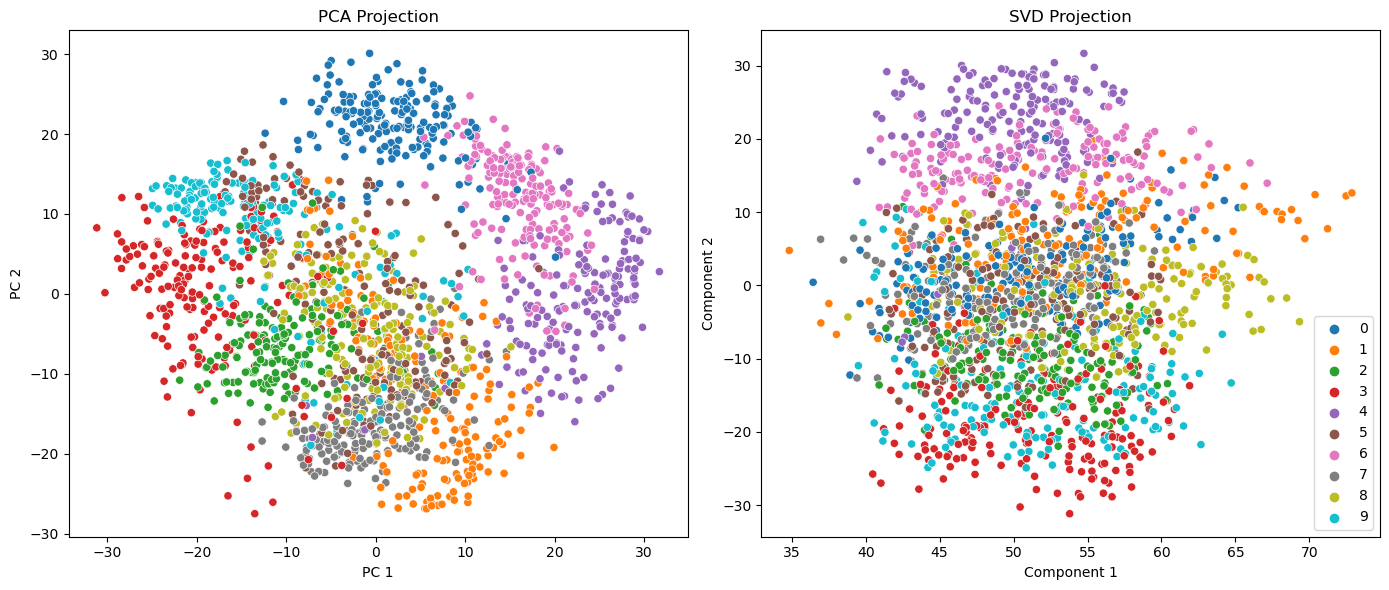

In [ ]:
# Compare PCA and Truncated SVD Projections

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# - Create a 1-row, 2-column subplot layout
# - figsize=(14, 6) makes both plots wider and readable

# PCA Projection Plot
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=y, ax=ax1,
    palette='tab10', legend=None  # Legend is turned off here to reduce clutter
)
ax1.set_title('PCA Projection')  # Title for PCA subplot
ax1.set_xlabel('PC 1')           # Label x-axis
ax1.set_ylabel('PC 2')           # Label y-axis

# SVD Projection Plot
sns.scatterplot(
    x=X_svd[:, 0], y=X_svd[:, 1], hue=y, ax=ax2,
    palette='tab10'              # Use same color palette for consistency
)
ax2.set_title('SVD Projection')  # Title for SVD subplot
ax2.set_xlabel('Component 1')    # Label x-axis
ax2.set_ylabel('Component 2')    # Label y-axis

plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()          # Display the plots

# - Both PCA and SVD reduce the original 64-dimensional digit data to 2D space.
# - You can visually compare how each method separates the digit clusters.
# - PCA and SVD often give **very similar results** for dense numeric data like images.
# - Differences may emerge in performance or clustering tightness, especially for sparse/text datasets.
# - In most real-world structured datasets, **PCA and Truncated SVD can be used interchangeably**,
#   but **SVD is better for sparse data**, while **PCA is more common for dense, normalized input**.


Part 4: t-SNE (t-Distributed Stochastic Neighbor Embedding)
Apply t-SNE

In [ ]:
# Apply t-SNE for non-linear dimensionality reduction

from sklearn.manifold import TSNE  # Import t-SNE from sklearn

# Create a t-SNE model with specified hyperparameters
tsne = TSNE(
    n_components=2,        # Reduce to 2D space for visualization
    perplexity=30,         # Controls the balance between local and global aspects (typical range: 5–50)
    learning_rate=200,     # Step size in optimization; too high/low can hurt clustering
    n_iter=1000,           # Number of optimization iterations
    random_state=42        # Ensures reproducibility
)

# Fit and transform the original data into 2D using t-SNE
X_tsne = tsne.fit_transform(X)
# - t-SNE works by converting high-dimensional Euclidean distances into probabilities.
# - It then tries to preserve these similarities in a lower-dimensional space.
# - Compared to PCA/SVD, t-SNE is **non-linear** and excels at visual cluster separation.

# Check the shape of the new dataset
print("Shape after t-SNE:", X_tsne.shape)


# - Original shape was (1797, 64), now it’s (1797, 2) , ready for 2D visualization.
# - Unlike PCA/SVD, t-SNE doesn't preserve global distances — it's designed to **group similar points together** visually.
# - This often leads to clearer **cluster separation**, especially in complex or curved data manifolds.
# - t-SNE is often used for **visual diagnostics**, not for downstream modeling (since it's not a true transformation).


Shape after t-SNE: (1797, 2)


Visualize t-SNE Results

In [ ]:
# Visualize the t-SNE results in 2D

plt.figure(figsize=(8,6))  # Set the plot size (8 inches wide by 6 inches high)

# Create a 2D scatter plot using Seaborn
sns.scatterplot(
    x=X_tsne[:, 0],             # First t-SNE component on X-axis
    y=X_tsne[:, 1],             # Second t-SNE component on Y-axis
    hue=y,                      # Use true digit labels (0–9) for color coding
    palette='tab10'             # Color palette with 10 distinct colors
)

# Add title and axis labels
plt.title("t-SNE Projection of Digits Dataset")        # Title of the plot
plt.xlabel("t-SNE Component 1")                        # X-axis label
plt.ylabel("t-SNE Component 2")                        # Y-axis label
plt.show()  # Display the plot


# - Each point represents one digit image, now reduced from 64D to 2D using t-SNE.
# - t-SNE is **non-linear**, so it excels at revealing natural clusters.
# - You’ll likely see well-separated clusters where each color groups together tightly.
# - This indicates that the digits have distinctive shapes that t-SNE successfully preserved.
# - Better visual separation than PCA/SVD, but **not suitable for feature engineering** (due to randomness and non-linearity).


# Final Insights & Recommendations: Dimensionality Reduction Techniques

| Method | Type       | Best Use                              | Speed       | Interpretability               |
|--------|------------|----------------------------------------|-------------|--------------------------------|
| PCA    | Linear     | Fast, interpretable, ML preprocessing  | Fast        | Moderate (linear combinations) |
| SVD    | Linear     | NLP, sparse data                       | Fast        | Moderate                       |
| t-SNE  | Non-linear | Data exploration, visualization        | Slow        | Low (non-deterministic)        |

## Recommendations by Use Case

| Use Case                                  | Recommended Method |
|-------------------------------------------|---------------------|
| Preprocessing for supervised ML models    | PCA or SVD          |
| Visualizing high-dimensional image data   | t-SNE               |
| Clustering structure understanding        | t-SNE               |
| Text data or sparse matrices              | SVD                 |
| Need for speed and interpretability       | PCA                 |
| Downstream model training (not just visuals) | PCA / SVD         |

## Notes
- PCA: Best when data is centered and features are correlated.
- SVD: Ideal for sparse or text data (e.g., TF-IDF in NLP).
- t-SNE: Great for visualizing clusters; not suitable for modeling or transforming new data.


Dimensionality Reduction on MNIST Dataset
Dataset Overview

In [23]:
# Load and Explore the MNIST Dataset

# Import required libraries
from tensorflow.keras.datasets import mnist        # Built-in utility to download/load the MNIST digit dataset
import matplotlib.pyplot as plt                    # For plotting and visualization
import seaborn as sns                              # For advanced visualizations (heatmaps, color themes)
import numpy as np                                 # For numerical operations and array handling

# Load the MNIST dataset
(X_train, y_train), (_, _) = mnist.load_data()
# - Returns: (X_train, y_train), (X_test, y_test)
# - X_train: 60,000 training images, each 28x28 pixels in grayscale
# - y_train: Corresponding labels (integers 0–9)
# - We ignore the test set here by replacing it with (_, _)

# Display the structure of training data
print("Shape of training images:", X_train.shape)  # Output: (60000, 28, 28)
# → 60,000 images, each of size 28x28 (2D grayscale)

print("Shape of labels:", y_train.shape)           # Output: (60000,)
# → 60,000 integer labels indicating the digit (0 to 9)

# Dataset Summary:
# - **MNIST** (Modified National Institute of Standards and Technology) is a benchmark dataset.
# - Contains 70,000 total grayscale handwritten digits: 60,000 for training, 10,000 for testing.
# - Each digit is a 28×28 pixel image with values from 0 (white) to 255 (black).
# - Widely used for image classification, clustering, and dimensionality reduction techniques (like PCA, t-SNE).


Shape of training images: (60000, 28, 28)
Shape of labels: (60000,)


Preview Sample Images

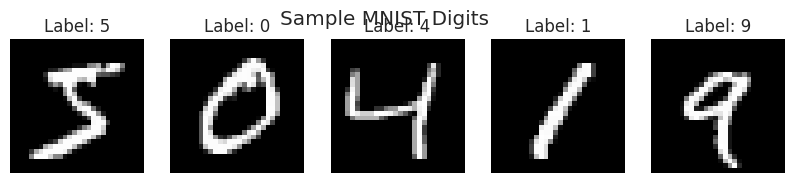

In [24]:
# Preview Sample MNIST Images

# Plot a few images to understand the data visually
plt.figure(figsize=(10, 2))
# - Create a figure of size 10x2 inches to display images in one horizontal row

for i in range(5):
    plt.subplot(1, 5, i+1)
    # - Create a subplot grid: 1 row, 5 columns
    # - i+1 because subplot index starts at 1 (not 0)

    plt.imshow(X_train[i], cmap='gray')
    # - Display the i-th image using a grayscale colormap
    # - Each image is 28x28 pixels and stored as a 2D array

    plt.title(f"Label: {y_train[i]}")
    # - Set the title above the image showing the actual digit label

    plt.axis('off')
    # - Hide the x and y axis ticks and frames for a cleaner look

plt.suptitle("Sample MNIST Digits")
# - Add an overall title to the row of images

plt.show()
# - Render and display the figure


# - This step gives a **visual intuition** of how MNIST digits appear.
# - Each image is a digit (0–9) written by different peop


Flatten Images for Dimensionality Reduction

In [25]:
# Flatten MNIST Images for Analysis

# Flatten each 28x28 image to a 1D array of 784 features
X_flat = X_train.reshape(-1, 28*28)
# - The reshape() function converts each 2D image (28 rows × 28 columns) into a 1D vector of 784 pixels
# - -1 automatically infers the number of samples (i.e., 60000 here)
# - The result is a 2D array of shape (60000, 784)

print("Flattened shape:", X_flat.shape)



# - Most machine learning models (including PCA and SVD) expect input as 2D arrays: (n_samples, n_features)
# - We are converting image matrices to vectors to feed into dimensionality reduction algorithms
# - Now, each image is a single row in a table with 784 features (pixel intensity values from 0–255)


Flattened shape: (60000, 784)


PCA on MNIST
Apply PCA(2 Components )

In [26]:
# Apply PCA to Reduce Dimensions to 2D

from sklearn.decomposition import PCA  # Import PCA from scikit-learn

# Reduce dimensionality to 2 components for visualization
pca = PCA(n_components=2)
# - n_components=2 means we want to project the high-dimensional data into 2D space
# - PCA finds the two directions (principal components) that capture the most variance

X_pca = pca.fit_transform(X_flat)
# - fit_transform() both fits the PCA model and applies the transformation
# - Input: X_flat (60000 samples × 784 pixel features)
# - Output: X_pca (60000 samples × 2 principal components)

print("Explained variance ratio:", pca.explained_variance_ratio_)
# - Shows the proportion of total variance explained by each of the 2 components
# - Helps us understand how much of the original information is retained


# - PCA compresses each 784-dimensional image into just 2 numbers (principal components)
# - These components capture the **directions of maximum variance** in the data
# - The explained_variance_ratio_ tells us how much "information" (variance) each PC holds
# - Though 2D PCA loses a lot of detail, it's very useful for **visualizing structure and clustering**


Explained variance ratio: [0.09704664 0.07095924]


Visualize PCA Results

In [27]:
# Visualize the 2D PCA Projection of MNIST

sns.set(style="whitegrid", palette="muted")
# - Set Seaborn's plot style to white grid with a muted color palette
# - Improves plot readability and aesthetics

plt.figure(figsize=(10, 6))
# - Set the size of the figure to 10 inches wide by 6 inches tall

sns.scatterplot(
    x=X_pca[:, 0],                   # X-axis: First principal component
    y=X_pca[:, 1],                   # Y-axis: Second principal component
    hue=y_train,                     # Color each point by its digit label (0–9)
    legend='full',                   # Show a full legend mapping colors to digits
    palette='tab10',                 # Use a 10-color palette (suitable for 10 classes)
    s=10                             # Set marker size to 10 for better clarity with 60,000 points
)

plt.title("PCA Projection of MNIST (2D)")  # Set plot title
plt.xlabel("Principal Component 1")        # Label for x-axis
plt.ylabel("Principal Component 2")        # Label for y-axis
plt.show()                                 # Display the plot


# - Each point is a 28x28 digit image, reduced to 2D via PCA
# - Points with the same digit label tend to form **clusters**, although there may be overlaps
# - PCA is **linear**, so it's great for capturing broad structure but may not separate similar digits like 4 vs 9 clearly
# - This plot gives an intuitive **visual summary of how digits are distributed** in the principal component space


Explained Variance Curve

In [28]:
# Analyze Cumulative Explained Variance of All PCA Components

pca_full = PCA().fit(X_flat)
# - Create a PCA model without limiting the number of components
# - This fits the model to capture **all 784 principal components**
# - Allows us to analyze how many components are required to retain most of the information

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
# - Compute the **cumulative sum** of explained variance ratios
# - Shows how much total variance is retained as we add more components (e.g., PC1 + PC2 + ... + PCN)

# Plot the cumulative explained variance (first 100 components)
plt.plot(cumulative_variance[:100])
# - Plot only the first 100 components for clarity (full plot would go up to 784)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Threshold')
# - Draw a horizontal dashed red line at 95% to highlight the threshold often used in dimensionality reduction

plt.legend()
plt.title("Explained Variance vs PCA Components")
plt.grid(True)
plt.show()


# - This plot helps determine the **optimal number of principal components** to retain desired variance.
# - For MNIST, ~95% of the variance is typically captured by the **first 150 components or fewer**.
# - This allows us to reduce dimensionality from 784 to ~100–150 dimensions with minimal information loss.
# - Useful for performance tuning and compression before feeding data to ML models or clustering.


SVD on MNIST, Apply Truncated SVD on Flattened Data

In [29]:
# Apply and Re-run Truncated SVD on MNIST for Verification or Reuse

from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD from sklearn

# Take 2 components to reduce the dimensionality to 2D
svd = TruncatedSVD(n_components=2)
# - TruncatedSVD is a linear dimensionality reduction technique.
# - It's similar to PCA, but does NOT require centering the data (no mean subtraction).
# - Often used for high-dimensional and sparse data like text and images.

X_svd = svd.fit_transform(X_flat)
# - Input: X_flat is the flattened MNIST image data with shape (60000, 784)
# - Output: X_svd will be (60000, 2) — a 2D representation of each handwritten digit

print("Explained variance (SVD):", svd.explained_variance_ratio_)
# - Displays the proportion of variance captured by each of the 2 components
# - Since we're reducing from 784 to 2 components, expect a very small fraction (< 10%) of total variance

print("Shape after SVD:", X_svd.shape)
# - Confirms that our dimensionality reduction worked as expected as (60000, 2)


# - SVD provides a **linear projection** of the digit images into a 2D space.
# - Because it doesn't model non-linear structure, **some digit classes may overlap** visually.
# - This makes it good for quick structure discovery and comparison with other techniques like PCA.
# - But for deeper patterns (e.g., curved clusters, tight digit separation), **t-SNE is preferred**.
# - The next step is to visualize this using a scatterplot to evaluate the separability of digit classes in 2D.


Explained variance (SVD): [0.05807749 0.08246405]
Shape after SVD: (60000, 2)


Visualize SVD Projection

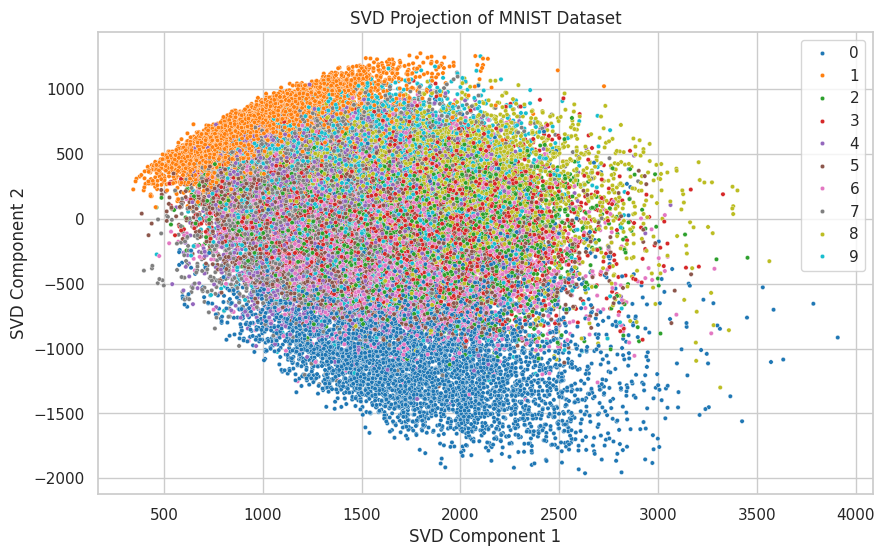

In [30]:
# Visualize Truncated SVD Projection of MNIST (2D)

plt.figure(figsize=(10, 6))
# - Create a wide canvas for the 2D scatter plot

sns.scatterplot(
    x=X_svd[:, 0],           # First SVD component
    y=X_svd[:, 1],           # Second SVD component
    hue=y_train,             # Use digit labels (0 to 9) as hue for coloring points
    palette='tab10',         # Use a colormap suitable for 10 classes
    s=10                     # Use small point size for better visibility
)

plt.title("SVD Projection of MNIST Dataset")
# - Set the title to describe what this 2D projection is showing

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.show()


# - Each point here represents a handwritten digit from MNIST, reduced to 2D using **Truncated SVD**.
# - SVD is a linear technique, similar to PCA, but it doesn't center the data.
# - This 2D plot attempts to show how digits (0–9) separate in low-dimensional space based on raw pixel intensity patterns.
# - You may observe:
#     - Some tight clusters (e.g., 0, 1, 8) where digits are clearly distinguishable.
#     - Some overlap for digits with similar shapes (e.g., 3 vs 5, 4 vs 9).
# - While useful for understanding global variance structure, **SVD doesn’t capture local relationships** as effectively as t-SNE.
# - This makes it a good first-step method for **fast visualization**, but not for deep structure or classification boundaries.


t-SNE on MNIST
Apply t-SNE

In [31]:
# Apply t-SNE for Non-Linear Dimensionality Reduction

from sklearn.manifold import TSNE  # Import t-SNE from scikit-learn

# Use a smaller sample due to t-SNE’s high computational cost
X_sample = X_flat[:3000]        # Take first 3000 images from flattened MNIST data
y_sample = y_train[:3000]       # Corresponding labels

#  t-SNE is computationally intensive and slow for large datasets.
# - That’s why we limit it to 3000 samples (a common practical strategy).
# - Reducing more samples increases runtime exponentially.

# Initialize t-SNE with key hyperparameters
tsne = TSNE(
    n_components=2,         # Reduce to 2D space for visualization
    perplexity=30,          # Balance between local vs global attention (typical range: 5–50)
    learning_rate=200,      # Step size for gradient descent (too high/low can hurt performance)
    max_iter=1000,           # Number of optimization iterations (1000 is good baseline)
    random_state=42         # Ensures reproducibility
)

# Apply t-SNE to the sampled data
X_tsne = tsne.fit_transform(X_sample)
# - t-SNE learns a new 2D representation that preserves **local structure** (how close points are)
# - Input: high-dimensional vectors (3000 × 784)
# - Output: new 2D coordinates for each point (3000 × 2)


# - Unlike PCA/SVD, t-SNE is **non-linear**, so it excels at revealing **clusters and complex manifolds**
# - It's ideal for visual exploration — the resulting plot often shows tightly packed digit groups
# - However, t-SNE does **not preserve global structure**, so distances between distant points are not meaningful
# - It's also **not suitable for downstream ML tasks** (like feature engineering), but great for **visual insights**


Visualize t-SNE results

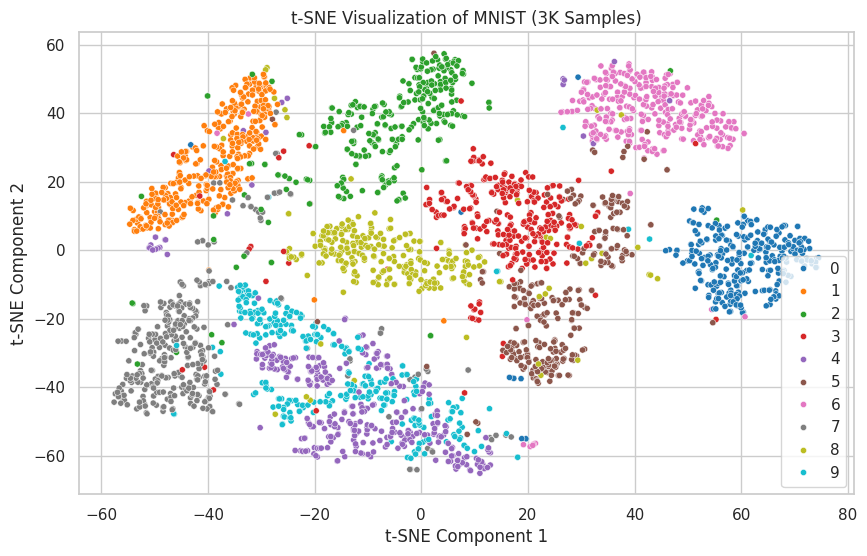

In [32]:
# Visualize t-SNE Results in 2D

plt.figure(figsize=(10, 6))
# - Create a figure of size 10x6 inches to clearly view clustered points

sns.scatterplot(
    x=X_tsne[:, 0],              # X-axis: first t-SNE component
    y=X_tsne[:, 1],              # Y-axis: second t-SNE component
    hue=y_sample,                # Color points by digit label (0–9)
    palette='tab10',             # Use a 10-color palette (one per digit)
    s=20                         # Marker size for each point
)

plt.title("t-SNE Visualization of MNIST (3K Samples)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


# - Each point represents a 28x28 digit image reduced to 2D via t-SNE.
# - You should see distinct **clusters** forming, where similar digits group tightly together.
# - Digits that are harder to distinguish (e.g., 4 vs 9) may have some overlap, showing t-SNE’s sensitivity.
# - This plot provides **insight into the intrinsic structure** of high-dimensional data.
# - Unlike PCA, t-SNE is better at showing **local relationships** and fine-grained clusters.
# - However, the distance between far-away clusters is **not meaningful** — only local groupings matter.


Dimensionality Reduction on CIFAR-10,
Load and Inspect CIFAR-10

In [33]:
# CIFAR-10 Dataset Overview and Loading

# Dataset Overview:
# - **CIFAR-10** is a labeled subset of the 80 million tiny images dataset.
# - It contains **60,000 color images**, each sized **32x32 pixels with 3 RGB channels**.
# - The dataset is split into:
#     - 50,000 training images
#     - 10,000 test images
# - There are **10 distinct classes**, representing common objects:
#     ['airplane', 'automobile', 'bird', 'cat', 'deer',
#      'dog', 'frog', 'horse', 'ship', 'truck']
# - Each image has 32 × 32 × 3 = **3072 features** when flattened.
# - It's more complex than MNIST because it contains real-world textures, shapes, and color variations.

# load the CIFAR-10 dataset

from tensorflow.keras.datasets import cifar10  # Keras provides built-in access to CIFAR-10

# Load training data (ignore test set)
(X_train, y_train), (_, _) = cifar10.load_data()
# - X_train: shape (50000, 32, 32, 3) → 50,000 images with RGB values
# - y_train: shape (50000, 1) → labels corresponding to the 10 classes
# - We’re ignoring the test set using (_, _) for now

y_train = y_train.flatten()
# - Convert label shape from (50000, 1) to (50000,) for easier usage in plots and ML tools

print("CIFAR-10 shape:", X_train.shape)
# Output: (50000, 32, 32, 3) this confirms 50k color images of 32x32x3 dimensions


CIFAR-10 shape: (50000, 32, 32, 3)


 Visualize Sample Images

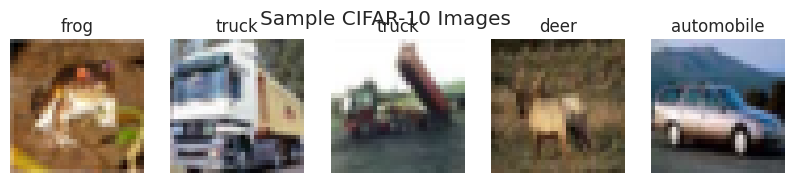

In [34]:
# Visualize Sample Images from CIFAR-10

# What?
# - Displaying 5 sample images from the CIFAR-10 training set
# - Each image is color (RGB), 32x32 pixels
# - Labels are mapped to class names for readability

# Define the class names corresponding to CIFAR-10 labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 2))
# - Create a wide, short figure (10 inches wide × 2 inches tall) for displaying 5 small images in one row

for i in range(5):
    plt.subplot(1, 5, i + 1)
    # - Set up a subplot grid with 1 row and 5 columns
    # - Plot the i-th image in the i+1-th position (subplots index from 1)

    plt.imshow(X_train[i])
    # - Display the i-th CIFAR image using RGB coloring
    # - Each image has shape (32, 32, 3)

    plt.title(class_names[y_train[i]])
    # - Use the integer label to get the class name (e.g., 'cat', 'ship') from the class_names list

    plt.axis('off')
    # - Turn off axes for cleaner visual presentation

plt.suptitle("Sample CIFAR-10 Images")
# - Add a common title above all subplots

plt.show()
# - Render and display the plot


# - This gives a quick **visual sanity check** on the dataset.
# - Helps confirm correct image loading and label mapping.
# - Note how small and colorful the CIFAR-10 images are — this increases dimensionality and complexity.


Flatten for Dimensionality Reduction

In [35]:
# Flatten CIFAR-10 Images for Dimensionality Reduction

X_flat = X_train.reshape(-1, 32*32*3)
# - Each CIFAR-10 image is originally of shape (32, 32, 3) → 32x32 pixels with 3 color channels (RGB)
# - We flatten each image into a 1D array of size 3072 (32 × 32 × 3)
# - reshape(-1, ...) means:
#     - "-1" lets NumPy automatically infer the number of rows (images) → here, 50,000
#     - So result = (50000, 3072), i.e., 50K images, each with 3072 features

print("Flattened CIFAR shape:", X_flat.shape)



# - This format is now suitable for machine learning algorithms that require 2D input:
#     (n_samples, n_features)
# - Each row is now a **single image**, and each column is a **pixel channel value**
# - This is a necessary preprocessing step before applying:
#     - PCA (Principal Component Analysis)
#     - SVD (Truncated Singular Value Decomposition)
#     - t-SNE (t-distributed Stochastic Neighbor Embedding)

Flattened CIFAR shape: (50000, 3072)


PCA on CIFAR-10,
Apply PCA

In [36]:
# Apply PCA (2D) and Visualize CIFAR-10 Data in Principal Component Space

from sklearn.decomposition import PCA  # Import PCA module

pca = PCA(n_components=2)
# - Initialize PCA to reduce high-dimensional data to just 2 components
# - PCA will find two orthogonal directions (principal components) that capture the most variance

X_pca = pca.fit_transform(X_flat)
# - Fit the PCA model to our flattened CIFAR-10 data (50000, 3072) and transform it
# - Output: X_pca will be of shape (50000, 2), i.e., 2D representation of all 50,000 images

# Plot the 2D PCA projection
plt.figure(figsize=(10, 6))
# - Create a wide plot canvas for better visualization

sns.scatterplot(
    x=X_pca[:, 0],                # First principal component on x-axis
    y=X_pca[:, 1],                # Second principal component on y-axis
    hue=y_train,                  # Color points based on their class label (0–9)
    palette='tab10',              # Use tab10 colormap (suitable for 10 classes)
    s=10,                         # Marker size set to 10 for dense data
    legend=None                   # Turn off legend to avoid clutter (50k points is too much)
)

plt.title("PCA Projection of CIFAR-10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# - PCA has reduced the 3072-dimensional color image data to just 2 principal components.
# - The scatter plot shows how CIFAR-10 classes are distributed in 2D based on their dominant variance directions.
# - Unlike MNIST, CIFAR-10 classes **overlap more** due to higher visual similarity and complexity.
# - Some separation may still be visible for classes with distinct features (e.g., ships vs horses).
# - However, PCA is linear and may not effectively capture complex patterns — non-linear methods like t-SNE work better here.


SVD on CIFAR-10

In [37]:
# Apply Truncated SVD to CIFAR-10 (2D Projection)

# Flatten the CIFAR-10 image dataset if not done already
# X_flat = X_train.reshape(-1, 32*32*3)
# (Already done in the previous step, so this line is commented out)

from sklearn.decomposition import TruncatedSVD  # Import Truncated SVD (a PCA-like method for sparse or large data)

svd_cifar = TruncatedSVD(n_components=2)
# - Initialize Truncated SVD to reduce dimensionality to 2 components
# - Similar to PCA, but it works better with **sparse matrices** and is often used in **text or image data**

X_svd_cifar = svd_cifar.fit_transform(X_flat)
# - Fit the SVD model and transform the flattened CIFAR data
# - Input: (50000, 3072) → Output: (50000, 2)

print("Explained variance (CIFAR SVD):", svd_cifar.explained_variance_ratio_)
# - This prints how much of the total variance is captured by each of the 2 components
# - Expected to be small since we’re compressing 3072 features into just 2


# - SVD gives a **linear projection** of high-dimensional image data, similar to PCA.
# - However, it doesn’t center the data like PCA does, so it may behave slightly differently.
# - It’s fast and scalable for large datasets, but like PCA, its 2D representation often fails to **cleanly separate complex classes** like those in CIFAR-10.
# - Still, it can help visualize **general patterns** or **outliers**.


Explained variance (CIFAR SVD): [0.26070848 0.12797957]


Visualize CIFAR-10 SVD Result

In [38]:
# Visualize the 2D SVD Projection of CIFAR-10

plt.figure(figsize=(10, 6))
# - Create a figure that’s 10 inches wide and 6 inches tall to hold the scatter plot

sns.scatterplot(
    x=X_svd_cifar[:, 0],        # X-axis: First SVD component
    y=X_svd_cifar[:, 1],        # Y-axis: Second SVD component
    hue=y_train,                # Color points by their CIFAR-10 class label (0–9)
    palette='tab10',            # Use the 'tab10' colormap — ideal for 10 categories
    s=10,                       # Point size = 10 (helps manage the 50k points visually)
    legend=False                # Disable legend to avoid clutter
)

plt.title("SVD Projection of CIFAR-10 Dataset")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.show()


# - Each dot represents a 32x32 color image, projected into 2D space using SVD.
# - Like PCA, SVD captures the two directions of **highest variance**, but **without centering the data**.
# - CIFAR-10 is **visually complex**, so this linear method doesn’t create clean clusters.
# - Overlaps between categories are expected, especially between visually similar classes like **automobiles vs trucks** or **cats vs dogs**.
# - Useful as a **baseline linear projection** before moving on to non-linear techniques like t-SNE or UMAP.


 t-SNE on CIFAR-10

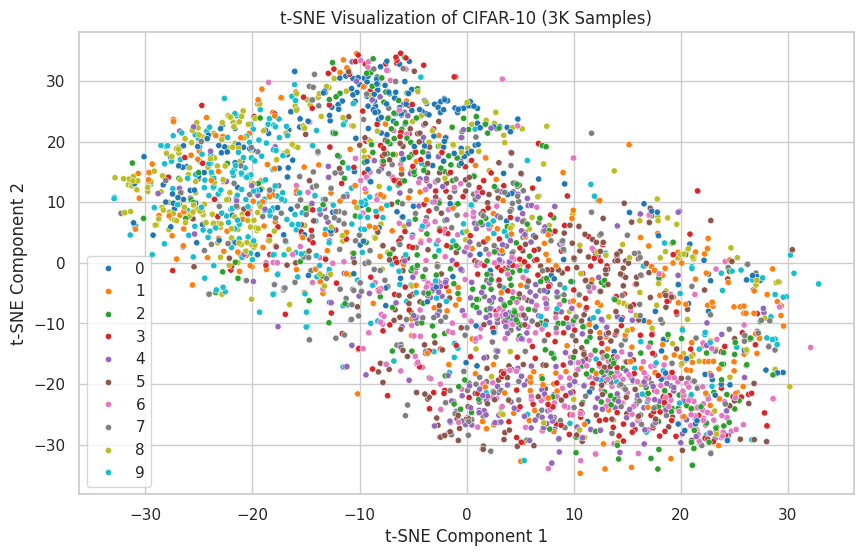

In [40]:
# Apply t-SNE for Non-Linear 2D Visualization of CIFAR-10

from sklearn.manifold import TSNE

#  t-SNE is computationally heavy, so we take only 3,000 samples
X_sample = X_flat[:3000]        # Flattened RGB images (3000 samples, 3072 features each)
y_sample = y_train[:3000]       # Corresponding labels

# Initialize t-SNE with common parameters
tsne = TSNE(
    n_components=2,             # Project down to 2D space
    perplexity=30,              # Controls balance between local and global structure (good default: 30)
    learning_rate=200,          # Step size during optimization (usually 10–1000)
    max_iter=1000                 # Number of optimization iterations (the higher, the better separation)
)

X_tsne = tsne.fit_transform(X_sample)
# - Learns a 2D embedding that preserves local neighbor relationships
# - Output: X_tsne has shape (3000, 2)


# - t-SNE emphasizes **local structure**: similar images (e.g., all 'cats') are placed close together
# - Unlike PCA/SVD, t-SNE is non-linear — it can **uncover complex structures and manifolds**
# - The output space has **no axes of interpretation** (components aren’t directions of variance)
# - Distances between distant clusters are not meaningful, but within-cluster proximity is!

# Plot the t-SNE result
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_tsne[:, 0],              # First t-SNE component
    y=X_tsne[:, 1],              # Second t-SNE component
    hue=y_sample,                # Color by class label (0–9)
    palette='tab10',             # Consistent 10-color palette
    s=20                         # Slightly larger points for clarity
)

plt.title("t-SNE Visualization of CIFAR-10 (3K Samples)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

# Visualization
# - now see **well-separated clusters** for some classes (like 'airplane' or 'ship')
# - Classes that are visually similar (e.g., 'dog' vs 'cat') may have overlapping clusters
# - t-SNE is ideal for **exploring structure**, not for downstream ML tasks (e.g., training classifiers)


MNIST – PCA vs SVD vs t-SNE Comparison

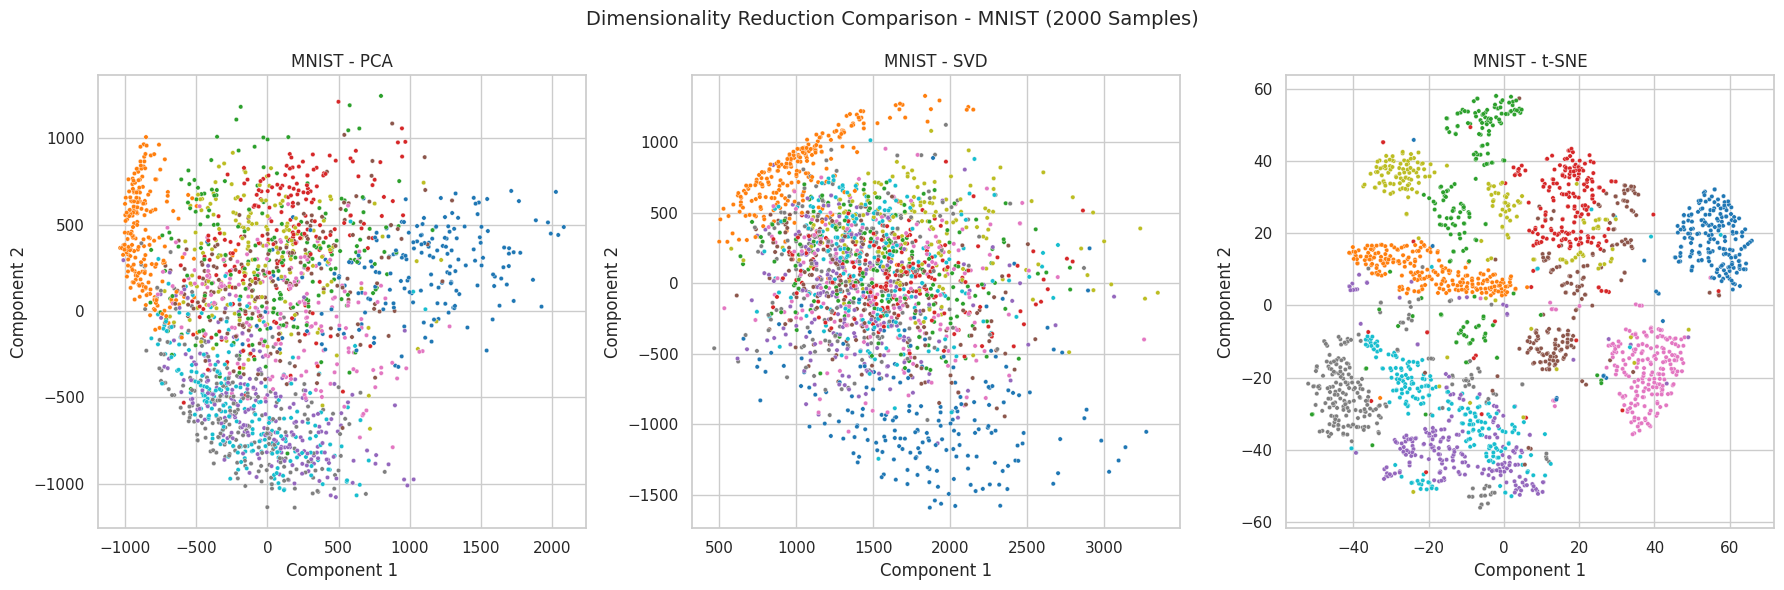

In [42]:
# PCA vs SVD vs t-SNE Comparison on MNIST

from tensorflow.keras.datasets import mnist
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess MNIST dataset
(X_mnist, y_mnist), _ = mnist.load_data()
# - Load 60,000 training images and labels from MNIST (each image is 28x28)

X_flat = X_mnist.reshape(-1, 28 * 28)
# - Flatten each image from (28, 28) , (784,) for dimensionality reduction

X_sample = X_flat[:2000]        # Use first 2000 samples for speed (especially for t-SNE)
y_sample = y_mnist[:2000]       # Corresponding labels

# Apply Dimensionality Reduction Techniques
X_pca = PCA(n_components=2).fit_transform(X_sample)
# - PCA: Linear method that projects data onto directions of highest variance

X_svd = TruncatedSVD(n_components=2).fit_transform(X_sample)
# - SVD: Similar to PCA but doesn’t center the data; good for sparse/high-dim data

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
).fit_transform(X_sample)
# - t-SNE: Non-linear technique that preserves local structure
# - Ideal for visualizing clusters, especially in image and text data
# - Slower, so we use only 2000 samples

# Plot Side-by-Side Comparisons
sns.set(style="whitegrid", palette="tab10")  # Nice plot style
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Create 3 side-by-side plots
titles = ['PCA', 'SVD', 't-SNE']                 # Titles for each method
data = [X_pca, X_svd, X_tsne]                    # 2D projections from each method

# Loop over each method to plot its result
for ax, method_data, title in zip(axes, data, titles):
    sns.scatterplot(
        x=method_data[:, 0],
        y=method_data[:, 1],
        hue=y_sample,
        s=10,
        ax=ax,
        palette='tab10',
        legend=False  # Avoid clutter
    )
    ax.set_title(f"MNIST - {title}")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# Add an overall title and layout fix
plt.suptitle("Dimensionality Reduction Comparison - MNIST (2000 Samples)", fontsize=14)
plt.tight_layout()
plt.show()


# PCA:
# - Captures global variance directions.
# - Good speed, interpretable axes.
# - Limited cluster separation for complex digits.

# SVD:
# - Similar to PCA but without mean-centering.
# - Also linear; results are often very close to PCA.
# - Fast and efficient but doesn't improve class separation.

# t-SNE:
# - Non-linear: excellent at capturing local relationships.
# - You’ll likely see **clearer digit clusters**, even if global layout is not meaningful.
# - Slow and sensitive to parameters, but very powerful for visualization.

# Use PCA/SVD for preprocessing; t-SNE for exploration & pattern discovery.


CIFAR-10: PCA vs SVD vs t-SNE

In [43]:
# PCA vs SVD vs t-SNE Comparison on CIFAR-10 (2000 Samples)

from tensorflow.keras.datasets import cifar10
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load and Preprocess CIFAR-10
(X_cifar, y_cifar), _ = cifar10.load_data()
# - CIFAR-10 has 60,000 color images of shape (32, 32, 3) in 10 classes
# - Each pixel has 3 RGB values (i.e., 32×32×3 = 3072 features per image)

X_flat = X_cifar.reshape(-1, 32 * 32 * 3)
# - Flatten each image from (32, 32, 3) to a 1D vector of 3072 pixels

y_cifar = y_cifar.flatten()
# - Flatten label array from shape (n,1) → (n,) for compatibility with Seaborn

X_sample = X_flat[:2000]         # Sample 2,000 images (t-SNE is slow for full set)
y_sample = y_cifar[:2000]        # Corresponding class labels

# Step 2: Apply Dimensionality Reduction
X_pca = PCA(n_components=2).fit_transform(X_sample)
# - PCA: Projects data onto the directions with highest global variance

X_svd = TruncatedSVD(n_components=2).fit_transform(X_sample)
# - SVD: Similar to PCA, linear, efficient for large/high-dimensional data

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
).fit_transform(X_sample)
# - t-SNE: Non-linear, excellent for visualizing clusters by preserving local neighborhoods
# - Works well for high-dimensional image features but is computationally expensive

# Step 3: Plot Comparison (Side-by-Side)
sns.set(style="whitegrid", palette="tab10")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Create 3 subplots side by side
titles = ['PCA', 'SVD', 't-SNE']                 # Titles for each subplot
data = [X_pca, X_svd, X_tsne]                    # Corresponding transformed datasets

for ax, method_data, title in zip(axes, data, titles):
    sns.scatterplot(
        x=method_data[:, 0],
        y=method_data[:, 1],
        hue=y_sample,
        s=10,
        ax=ax,
        palette='tab10',
        legend=False  # Suppress legend for cleaner view
    )
    ax.set_title(f"CIFAR-10 - {title}")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# Step 4: Final Layout
plt.suptitle("Dimensionality Reduction Comparison - CIFAR-10 (2000 Samples)", fontsize=14)
plt.tight_layout()
plt.show()


# PCA:
# - Linear method, finds directions of maximum global variance.
# - On CIFAR-10, class separation is weak due to visual complexity.
# - Good for fast compression but limited for visualization.

# SVD:
# - Linear like PCA, often gives very similar results.
# - May vary slightly due to lack of mean-centering.
# - Still not effective for complex visual classes like CIFAR-10.

# t-SNE:
# - Non-linear; focuses on preserving local structures (neighborhoods).
# - Often shows **better visual separation** of some CIFAR classes.
# - Slower and requires tuning, but better suited for cluster visualization.
# - Inter-cluster distances not meaningful; only local grouping matters.

# Summary:
# Use PCA/SVD for **dimensionality reduction before modeling**;
# Use t-SNE for **visual exploration and understanding class structure**.
